# **MMDA Project: linear and ensemble models training + evaluation**

In [ ]:
import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from nltk.corpus import words
from IPython.display import clear_output

RANDOM_STATE = 42
VAL_SIZE = 0.2
TEST_SIZE = 0.2
ENGLISH_QUOTA_THRESHOLD = 0.8

import warnings
warnings.filterwarnings('ignore')

In [ ]:
import nltk
nltk.download('words', quiet=True)

True

### Load data and split it:

In [ ]:
data = pd.read_csv("cyberbullying_tweets.csv")

data.dropna(inplace=True)

ENGLISH_WORDS = set(words.words())

def english_quota(text):
    if not isinstance(text, str):
        return 0
    word_list = re.findall(r'\b\w+\b', text.lower())
    if not word_list:
        return 0
    english_count = sum(1 for w in word_list if w in ENGLISH_WORDS)
    return english_count / len(word_list)

data["english_quota"] = data["tweet_text"].apply(english_quota)
data = data[data["english_quota"] >= ENGLISH_QUOTA_THRESHOLD].copy()

In [ ]:
# deduplication

data["tweet_text_dedup_key"] = data["tweet_text"].astype(str).str.strip().str.lower()
before_dedup = len(data)

# count labels for each duplicate text
label_counts = data.groupby(["tweet_text_dedup_key", "cyberbullying_type"]).size().reset_index(name="count")

# keep the majority label for every duplicated text
label_counts["max_count"] = label_counts.groupby("tweet_text_dedup_key")["count"].transform("max")
majority_labels = label_counts[label_counts["count"] == label_counts["max_count"]].copy()

# remove ambiguous duplicate groups where two or more labels are tied
tie_counts = majority_labels.groupby("tweet_text_dedup_key")["cyberbullying_type"].nunique()
non_ambiguous_keys = tie_counts[tie_counts == 1].index

majority_labels = majority_labels[
    majority_labels["tweet_text_dedup_key"].isin(non_ambiguous_keys)
][["tweet_text_dedup_key", "cyberbullying_type"]]

majority_labels = majority_labels.rename(
    columns={"cyberbullying_type": "majority_label"}
)

# keep one representative tweet for each non-ambiguous text
data = ( data
        .merge(majority_labels, on="tweet_text_dedup_key", how="inner")
        .drop_duplicates(subset="tweet_text_dedup_key", keep="first")
        .copy()
       )

# use the majority label as the final label
data["cyberbullying_type"] = data["majority_label"]

data = data.drop(columns=["majority_label"])
data = data.reset_index(drop=True)
data["row_id"] = data.index

after_dedup = len(data)

print("Rows after filtering and deduplication:", after_dedup)
print("Removed duplicate/ambiguous rows:", before_dedup - after_dedup)

# label encoding
le = LabelEncoder()
data["label"] = le.fit_transform(data["cyberbullying_type"])

id2label = {i: label for i, label in enumerate(le.classes_)}
label2id = {label: i for i, label in id2label.items()}

print("Classes:", id2label, "\n")
print(data["cyberbullying_type"].value_counts())

Rows after filtering and deduplication: 21117
Removed duplicate/ambiguous rows: 1310
Classes: {0: 'age', 1: 'ethnicity', 2: 'gender', 3: 'not_cyberbullying', 4: 'other_cyberbullying', 5: 'religion'} 

cyberbullying_type
age                    5952
gender                 3663
religion               3658
ethnicity              3403
other_cyberbullying    2331
not_cyberbullying      2110
Name: count, dtype: int64


In [ ]:
# split data, the same split will be used with transformers
train_val_idx, test_idx = train_test_split(
    data["row_id"].values,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=data["label"].values
)

train_val_df = data[data["row_id"].isin(train_val_idx)].copy()
test_df = data[data["row_id"].isin(test_idx)].copy()

train_idx, val_idx = train_test_split(
    train_val_df["row_id"].values,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_STATE,
    stratify=train_val_df["label"].values
)

train_df = data[data["row_id"].isin(train_idx)].copy()
val_df = data[data["row_id"].isin(val_idx)].copy()

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 12669
Validation size: 4224
Test size: 4224


### Data preprocessing and feature engineering:

I preprocessed data using the class TextPreprocessor from the file MMDA_Preprocessing.ipynb:

In [ ]:
%run 'MMDA_Preprocessing.ipynb'
clear_output()

In [10]:
preprocessing_config = {
    "lowercase": True,
    "remove_stopwords": True,
    "use_stemming": False,
    "use_lemmatization": True,
    "replace_urls": True,
    "replace_mentions": True,
    "normalize_mojibake": True,
    "remove_duplicates": False,
    "min_word_length": 2
}

preprocessor = TextPreprocessor(**preprocessing_config)

train_df["tokens"] = train_df["tweet_text"].apply(preprocessor.preprocess)
val_df["tokens"] = val_df["tweet_text"].apply(preprocessor.preprocess)
test_df["tokens"] = test_df["tweet_text"].apply(preprocessor.preprocess)

# remove empty texts after preprocessing
train_df = train_df[train_df["tokens"].apply(len) > 0].copy()
val_df = val_df[val_df["tokens"].apply(len) > 0].copy()
test_df = test_df[test_df["tokens"].apply(len) > 0].copy()

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

print("Train after removing empty tweets:", len(train_df))
print("Validation after removing empty tweets:", len(val_df))
print("Test after removing empty tweets:", len(test_df))

Train after removing empty tweets: 12662
Validation after removing empty tweets: 4224
Test after removing empty tweets: 4224


In [11]:
# final cleaned data after deduplication, filtering, and empty-tweet removal
final_cleaned_data = pd.concat([train_df, val_df, test_df], axis=0).sort_values("row_id")

final_cleaned_data.to_csv("cleaned_deduplicated_tweets.csv", index=False)
final_cleaned_data[["row_id", "cyberbullying_type"]].to_csv("cleaned_row_ids.csv", index=False)

train_df[["row_id", "cyberbullying_type"]].to_csv("train_final_row_ids.csv", index=False)
val_df[["row_id", "cyberbullying_type"]].to_csv("val_final_row_ids.csv", index=False)
test_df[["row_id", "cyberbullying_type"]].to_csv("test_final_row_ids.csv", index=False)

In [12]:
feature_engineer = FeatureEngineer(
    ngram_range=(1, 2),
    max_features=30000,
    min_df=3,
    max_df=0.9
)

# TF-IDF
X_train_tfidf = feature_engineer.extract_tfidf_features(train_df["tokens"], fit=True)
X_val_tfidf = feature_engineer.extract_tfidf_features(val_df["tokens"], fit=False)
X_test_tfidf = feature_engineer.extract_tfidf_features(test_df["tokens"], fit=False)

# meta features
train_meta_df = train_df[["tokens"]].copy()
val_meta_df = val_df[["tokens"]].copy()
test_meta_df = test_df[["tokens"]].copy()

X_train_meta = feature_engineer.extract_meta_features(train_meta_df, "tokens")
X_val_meta = feature_engineer.extract_meta_features(val_meta_df, "tokens")
X_test_meta = feature_engineer.extract_meta_features(test_meta_df, "tokens")

X_train_meta["english_quota"] = train_df["english_quota"].values
X_val_meta["english_quota"] = val_df["english_quota"].values
X_test_meta["english_quota"] = test_df["english_quota"].values

# scale numeric meta features
meta_scaler = StandardScaler(with_mean=False)

X_train_meta_scaled = meta_scaler.fit_transform(csr_matrix(X_train_meta.values))
X_val_meta_scaled = meta_scaler.transform(csr_matrix(X_val_meta.values))
X_test_meta_scaled = meta_scaler.transform(csr_matrix(X_test_meta.values))

# TF-IDF + meta features
X_train = hstack([X_train_tfidf, X_train_meta_scaled]).tocsr()
X_val = hstack([X_val_tfidf, X_val_meta_scaled]).tocsr()
X_test = hstack([X_test_tfidf, X_test_meta_scaled]).tocsr()

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF val shape:", X_val_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

print("\nMeta train shape:", X_train_meta.shape)
print("Meta val shape:", X_val_meta.shape)
print("Meta test shape:", X_test_meta.shape)

print("\nFinal train shape:", X_train.shape)
print("Final val shape:", X_val.shape)
print("Final test shape:", X_test.shape)

TF-IDF train shape: (12662, 12765)
TF-IDF val shape: (4224, 12765)
TF-IDF test shape: (4224, 12765)

Meta train shape: (12662, 10)
Meta val shape: (4224, 10)
Meta test shape: (4224, 10)

Final train shape: (12662, 12775)
Final val shape: (4224, 12775)
Final test shape: (4224, 12775)


### Training and evaluation:

In [13]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    result = {
        "model": model_name,
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(f"Accuracy:        {acc:.4f}")
    print(f"Macro precision: {precision:.4f}")
    print(f"Macro recall:    {recall:.4f}")
    print(f"Macro F1:        {f1:.4f}")
    print()
    print(classification_report(
        y_test,
        y_pred,
        target_names=le.classes_,
        digits=4,
        zero_division=0
    ))

    return result, y_pred

First, let's train simple linear models:

In [14]:
linear_models = {
    "Logistic Regression": LogisticRegression(
        C=4.0,
        max_iter=2000,
        solver="saga",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        multi_class="multinomial"
    ),

    "Linear SVM": LinearSVC(
        C=1.0,
        random_state=RANDOM_STATE
    ),

    "SGD Linear SVM": SGDClassifier(
        loss="hinge",
        alpha=1e-5,
        max_iter=1000,
        tol=1e-3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

val_results = []
val_predictions = {}

for name, model in linear_models.items():
    result, y_val_pred = evaluate_model(
        model,
        X_train,
        y_train,
        X_val,
        y_val,
        name
    )

    val_results.append(result)
    val_predictions[name] = y_val_pred

Logistic Regression
Accuracy:        0.8977
Macro precision: 0.8565
Macro recall:    0.8542
Macro F1:        0.8547

                     precision    recall  f1-score   support

                age     0.9688    0.9908    0.9797      1191
          ethnicity     0.9883    0.9941    0.9912       680
             gender     0.9316    0.8922    0.9115       733
  not_cyberbullying     0.6174    0.5545    0.5843       422
other_cyberbullying     0.6588    0.7210    0.6885       466
           religion     0.9740    0.9727    0.9733       732

           accuracy                         0.8977      4224
          macro avg     0.8565    0.8542    0.8547      4224
       weighted avg     0.8971    0.8977    0.8970      4224

Linear SVM
Accuracy:        0.8935
Macro precision: 0.8491
Macro recall:    0.8442
Macro F1:        0.8463

                     precision    recall  f1-score   support

                age     0.9555    0.9916    0.9732      1191
          ethnicity     0.9826    0.998

Now let's train ensemble models, starting with voting classifier over linear models:

In [15]:
voting_clf = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(
            C=4.0,
            max_iter=2000,
            solver="saga",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            multi_class="multinomial"
        )),
        ("svc", LinearSVC(
            C=1.0,
            random_state=RANDOM_STATE
        )),
        ("sgd", SGDClassifier(
            loss="hinge",
            alpha=1e-5,
            max_iter=1000,
            tol=1e-3,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )),
    ],
    voting="hard",
    n_jobs=-1
)

result, pred = evaluate_model(
    voting_clf,
    X_train,
    y_train,
    X_val,
    y_val,
    "Voting Ensemble: LR + SVC + SGD"
)

val_results.append(result)
val_predictions["Voting Ensemble: LR + SVC + SGD"] = pred

Voting Ensemble: LR + SVC + SGD
Accuracy:        0.8954
Macro precision: 0.8532
Macro recall:    0.8483
Macro F1:        0.8502

                     precision    recall  f1-score   support

                age     0.9610    0.9924    0.9765      1191
          ethnicity     0.9797    0.9956    0.9876       680
             gender     0.9174    0.9086    0.9130       733
  not_cyberbullying     0.5891    0.5877    0.5884       422
other_cyberbullying     0.7098    0.6245    0.6644       466
           religion     0.9625    0.9809    0.9716       732

           accuracy                         0.8954      4224
          macro avg     0.8532    0.8483    0.8502      4224
       weighted avg     0.8918    0.8954    0.8932      4224



Now we try to train tree-based ensemble models. Because of sparsity TF-IDF, we reduce TF-IDF with TruncatedSVD, then concatenate the meta-features.

In [16]:
N_COMPONENTS = 300

svd = TruncatedSVD(
    n_components=N_COMPONENTS,
    random_state=RANDOM_STATE
)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd = svd.transform(X_val_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

# dense meta-features
X_train_meta_dense = X_train_meta_scaled.toarray()
X_val_meta_dense = X_val_meta_scaled.toarray()
X_test_meta_dense = X_test_meta_scaled.toarray()

# reduced TF-IDF + meta-features
X_train_dense = np.hstack([X_train_svd, X_train_meta_dense])
X_val_dense = np.hstack([X_val_svd, X_val_meta_dense])
X_test_dense = np.hstack([X_test_svd, X_test_meta_dense])

print("Dense train shape:", X_train_dense.shape)
print("Dense val shape:", X_val_dense.shape)
print("Dense test shape:", X_test_dense.shape)
print("Explained variance by SVD:", svd.explained_variance_ratio_.sum())

Dense train shape: (12662, 310)
Dense val shape: (4224, 310)
Dense test shape: (4224, 310)
Explained variance by SVD: 0.2913758073362848


In [17]:
tree_ensemble_models = {
    "Random Forest on SVD features": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=None
    ),

    "Extra Trees on SVD features": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=None
    ),

    "HistGradientBoosting on SVD features": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    )
}

for name, model in tree_ensemble_models.items():
    result, pred = evaluate_model(
        model,
        X_train_dense,
        y_train,
        X_val_dense,
        y_val,
        name
    )
    val_results.append(result)
    val_predictions[name] = pred

Random Forest on SVD features
Accuracy:        0.8819
Macro precision: 0.8425
Macro recall:    0.8293
Macro F1:        0.8295

                     precision    recall  f1-score   support

                age     0.9299    0.9916    0.9598      1191
          ethnicity     0.9769    0.9941    0.9854       680
             gender     0.9295    0.8813    0.9048       733
  not_cyberbullying     0.6489    0.4028    0.4971       422
other_cyberbullying     0.5948    0.7403    0.6597       466
           religion     0.9752    0.9658    0.9705       732

           accuracy                         0.8819      4224
          macro avg     0.8425    0.8293    0.8295      4224
       weighted avg     0.8802    0.8819    0.8769      4224

Extra Trees on SVD features
Accuracy:        0.8819
Macro precision: 0.8372
Macro recall:    0.8275
Macro F1:        0.8286

                     precision    recall  f1-score   support

                age     0.9256    0.9924    0.9579      1191
          et

### Results and comparison:

In [18]:
val_results_df = pd.DataFrame(val_results)
val_results_df = val_results_df.sort_values("macro_f1", ascending=False)
val_results_df.round(4)

,model,accuracy,macro_precision,macro_recall,macro_f1
0,Logistic Regression,0.8977,0.8565,0.8542,0.8547
3,Voting Ensemble: LR + SVC + SGD,0.8954,0.8532,0.8483,0.8502
1,Linear SVM,0.8935,0.8491,0.8442,0.8463
6,HistGradientBoosting on SVD features,0.8852,0.8384,0.8369,0.8370
4,Random Forest on SVD features,0.8819,0.8425,0.8293,0.8295
5,Extra Trees on SVD features,0.8819,0.8372,0.8275,0.8286
2,SGD Linear SVM,0.8234,0.8056,0.7530,0.7475


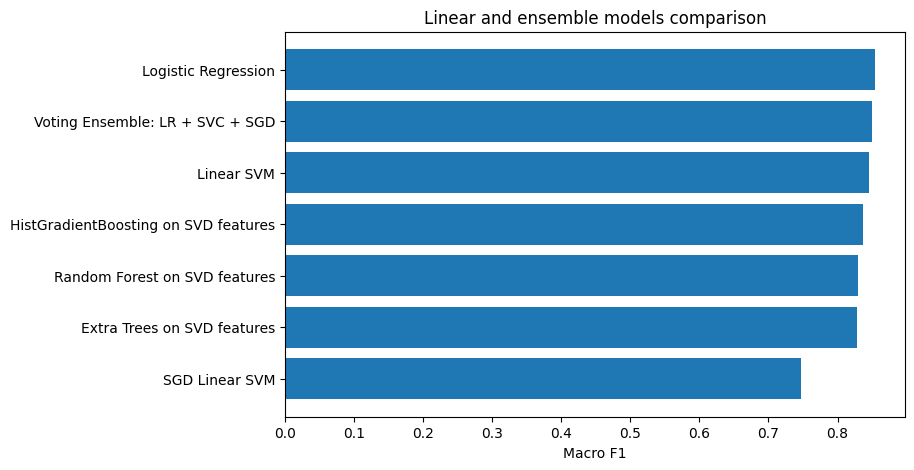

In [20]:
plt.figure(figsize=(8, 5))
plt.barh(val_results_df["model"], val_results_df["macro_f1"])
plt.xlabel("Macro F1")
plt.title("Linear and ensemble models comparison")
plt.gca().invert_yaxis()
plt.show()

As we can see, among the evaluated models, Logistic Regression achieved the highest validation-set macro F1. The second highest validation-set macro F1 was achieved by Voting classifier over linear models, which metric results not far away from LR.

Now let's look at the confusion matrix of the best evaluated model:

Model name: Logistic Regression


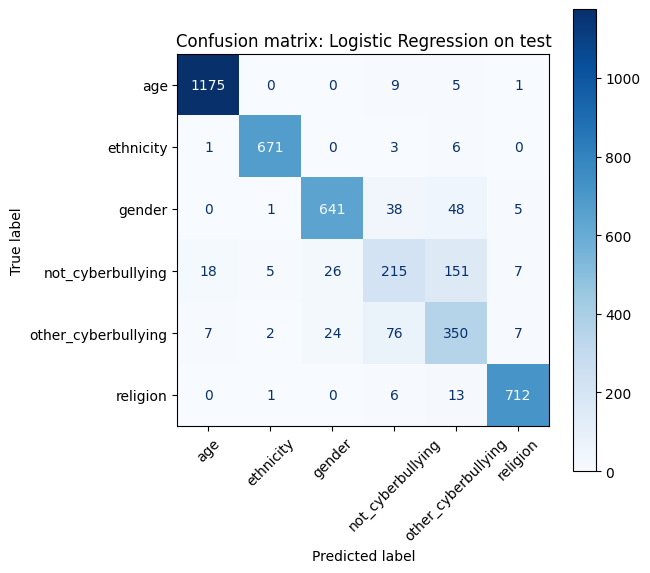

In [22]:
best_model_name = val_results_df.iloc[0]["model"]
best_model = linear_models[best_model_name]

print("Model name:", best_model_name)

# final test prediction
best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)
plt.title(f"Confusion matrix: {best_model_name} on test")
plt.show()

Final results of best linear model on test set:

In [23]:
final_result, y_test_pred = evaluate_model(
    best_model,
    X_train,
    y_train,
    X_test,
    y_test,
    best_model_name + " final test"
)

Logistic Regression final test
Accuracy:        0.8911
Macro precision: 0.8493
Macro recall:    0.8467
Macro F1:        0.8458

                     precision    recall  f1-score   support

                age     0.9784    0.9874    0.9829      1190
          ethnicity     0.9868    0.9853    0.9860       681
             gender     0.9276    0.8745    0.9003       733
  not_cyberbullying     0.6196    0.5095    0.5592       422
other_cyberbullying     0.6108    0.7511    0.6737       466
           religion     0.9727    0.9727    0.9727       732

           accuracy                         0.8911      4224
          macro avg     0.8493    0.8467    0.8458      4224
       weighted avg     0.8935    0.8911    0.8908      4224



Now let's look at the feature importance for the Logistic Regression model:

In [24]:
tfidf_feature_names = feature_engineer.tfidf_vectorizer.get_feature_names_out()
meta_feature_names = X_train_meta.columns.to_numpy()
all_feature_names = np.concatenate([tfidf_feature_names, meta_feature_names])

def plot_top_features(feature_names, importances, title, top_n=25):
    top_idx = np.argsort(importances)[-top_n:]

    plt.figure(figsize=(7, 5))
    plt.barh(feature_names[top_idx], importances[top_idx])
    plt.xlabel("Importance")
    plt.title(title)
    plt.tight_layout()
    plt.show()

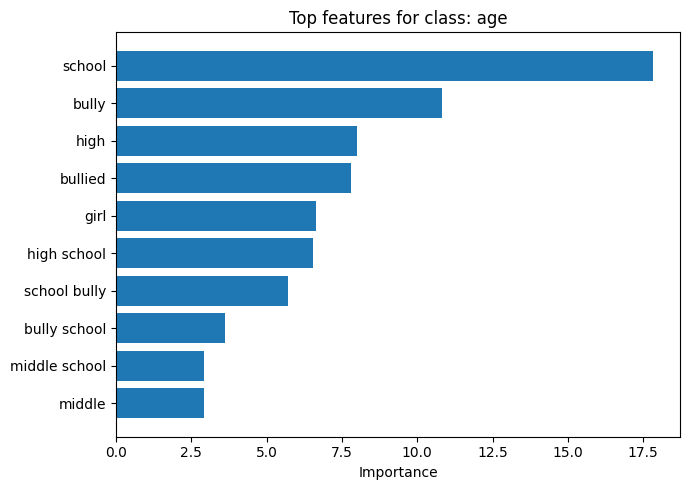

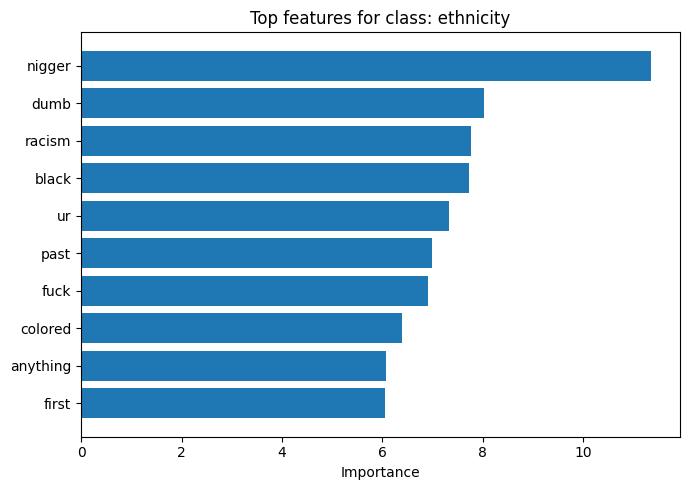

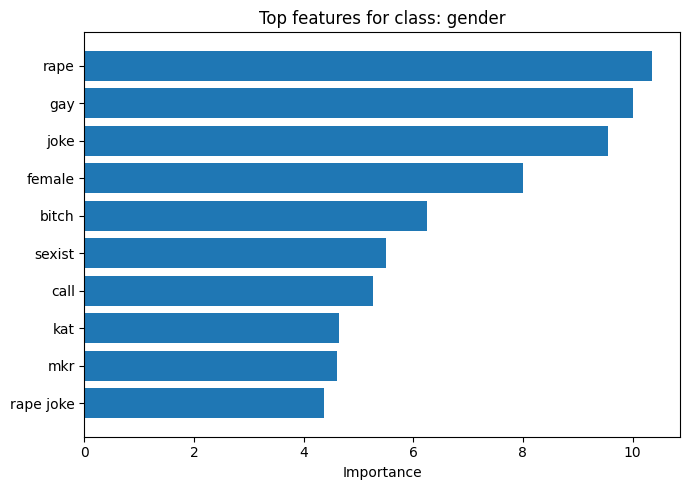

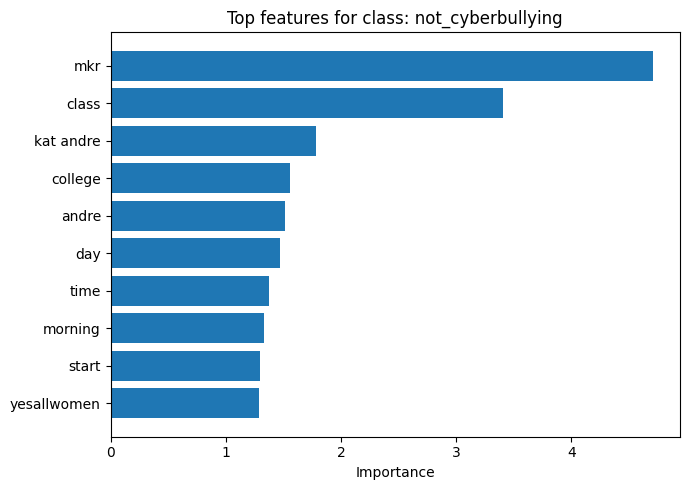

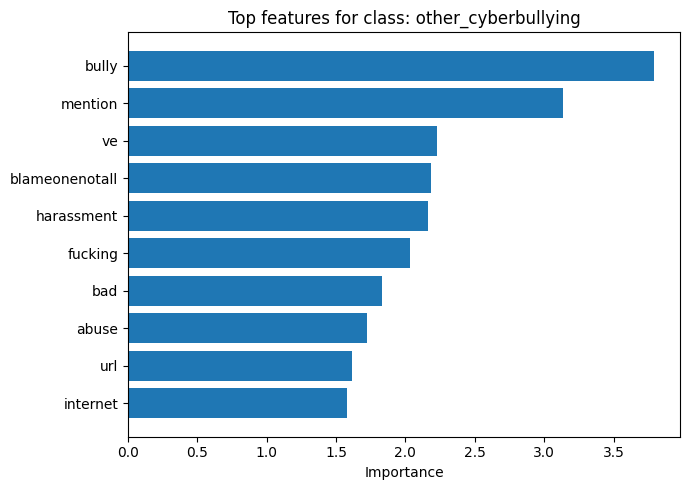

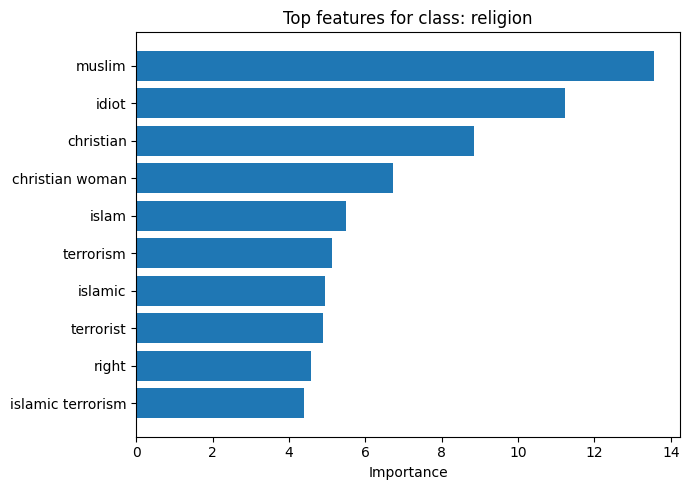

In [25]:
best_model.fit(X_train, y_train)

coef = best_model.coef_

for class_id, class_name in enumerate(le.classes_):
    class_importance = coef[class_id]
    top_idx = np.argsort(class_importance)[-10:][::-1]

    plot_top_features(
        all_feature_names,
        class_importance,
        f"Top features for class: {class_name}",
        top_n=10
    )

### Error analysis:

In [26]:
best_predictions_df = pd.DataFrame({
    "row_id": test_df["row_id"].values,
    "tweet_text": test_df["tweet_text"].values,
    "y_true": y_test,
    "y_pred": best_pred,
    "true_label": le.inverse_transform(y_test),
    "pred_label": le.inverse_transform(best_pred)
})

best_predictions_df["is_error"] = (
    best_predictions_df["true_label"] != best_predictions_df["pred_label"]
)

best_predictions_df.to_csv("linear_ensemble_best_predictions.csv", index=False)
best_predictions_df.head()

,row_id,tweet_text,y_true,y_pred,true_label,pred_label,is_error
0,1,Karma. I hope it bites Kat on the butt. She is...,3,2,not_cyberbullying,gender,True
1,3,"I still have Jack, Amsterdam, Ciroc, Crown, Bu...",3,3,not_cyberbullying,not_cyberbullying,False
2,5,You know there are people out there who like @...,3,3,not_cyberbullying,not_cyberbullying,False
3,11,no one ever help.me like my bully @AlwaysVero_...,3,4,not_cyberbullying,other_cyberbullying,True
4,12,You look like a gypsy. Sorry I'm not sorry.,3,4,not_cyberbullying,other_cyberbullying,True


In [29]:
errors_df = best_predictions_df[best_predictions_df["y_true"] != best_predictions_df["y_pred"]].copy()

print("Number of errors:", len(errors_df))
errors_df.head()

Number of errors: 460


,row_id,tweet_text,y_true,y_pred,true_label,pred_label,is_error
0,1,Karma. I hope it bites Kat on the butt. She is...,3,2,not_cyberbullying,gender,True
3,11,no one ever help.me like my bully @AlwaysVero_...,3,4,not_cyberbullying,other_cyberbullying,True
4,12,You look like a gypsy. Sorry I'm not sorry.,3,4,not_cyberbullying,other_cyberbullying,True
5,15,@Bahai144 ROFLMAO. So all this time I've been...,3,4,not_cyberbullying,other_cyberbullying,True
7,26,@Kaya786 @fai3an_H And I don't walk in circles...,3,4,not_cyberbullying,other_cyberbullying,True


In [30]:
error_summary = errors_df.groupby(["true_label", "pred_label"]).size().reset_index(name="count").sort_values("count", ascending=False)
error_summary.head()

,true_label,pred_label,count
13,not_cyberbullying,other_cyberbullying,151
18,other_cyberbullying,not_cyberbullying,76
8,gender,other_cyberbullying,48
7,gender,not_cyberbullying,38
12,not_cyberbullying,gender,26


Logistic Regression does not classify correctly 460 tweets.

### Saving models

In [ ]:
import joblib
import os
from datetime import datetime

# Create directory for saving final models
MODEL_DIR = "saved_final_models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Optional: create timestamped subdirectory
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
final_model_dir = os.path.join(MODEL_DIR, f"final_models_{timestamp}")
os.makedirs(final_model_dir, exist_ok=True)

print(f"Saving final models to: {final_model_dir}")

In [ ]:
# Dictionary to store final trained models
final_linear_models = {}

for name, model in linear_models.items():
    # Train on full training data (X_train)
    model.fit(X_train, y_train)
    
    # Save the final trained model
    model_filename = f"{name.replace(' ', '_').replace(':', '')}.joblib"
    model_path = os.path.join(final_model_dir, model_filename)
    joblib.dump(model, model_path)
    final_linear_models[name] = model
    
    # Evaluate on validation set
    y_val_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_val, y_val_pred, average="macro", zero_division=0
    )
    
    result = {
        "model": name,
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }
    
    print("=" * 80)
    print(name)
    print("=" * 80)
    print(f"Accuracy:        {acc:.4f}")
    print(f"Macro precision: {precision:.4f}")
    print(f"Macro recall:    {recall:.4f}")
    print(f"Macro F1:        {f1:.4f}")
    print()
    print(classification_report(y_val, y_val_pred, target_names=le.classes_, digits=4, zero_division=0))
    
    val_results.append(result)
    val_predictions[name] = y_val_pred

In [ ]:
# Train and save voting classifier
voting_clf = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(
            C=4.0,
            max_iter=2000,
            solver="saga",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            multi_class="multinomial"
        )),
        ("svc", LinearSVC(
            C=1.0,
            random_state=RANDOM_STATE
        )),
        ("sgd", SGDClassifier(
            loss="hinge",
            alpha=1e-5,
            max_iter=1000,
            tol=1e-3,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )),
    ],
    voting="hard",
    n_jobs=-1
)

# Train on full training data
voting_clf.fit(X_train, y_train)

# Save the final voting classifier
joblib.dump(voting_clf, os.path.join(final_model_dir, "Voting_Ensemble.joblib"))

# Evaluate on validation set
result, pred = evaluate_model(
    voting_clf,
    X_train,
    y_train,
    X_val,
    y_val,
    "Voting Ensemble: LR + SVC + SGD"
)

val_results.append(result)
val_predictions["Voting Ensemble: LR + SVC + SGD"] = pred

In [ ]:
# Train and save tree-based models
final_tree_models = {}

for name, model in tree_ensemble_models.items():
    # Train on dense features
    model.fit(X_train_dense, y_train)
    
    # Save the final trained model
    model_filename = f"{name.replace(' ', '_').replace(':', '')}.joblib"
    model_path = os.path.join(final_model_dir, model_filename)
    joblib.dump(model, model_path)
    final_tree_models[name] = model
    
    # Evaluate on validation set
    result, pred = evaluate_model(
        model,
        X_train_dense,
        y_train,
        X_val_dense,
        y_val,
        name
    )
    val_results.append(result)
    val_predictions[name] = pred

In [ ]:
# Save all preprocessing objects needed for SHAP analysis
preprocessing_objects = {
    'tfidf_vectorizer': feature_engineer.tfidf_vectorizer,
    'meta_scaler': meta_scaler,
    'svd': svd,
    'label_encoder': le,
    'feature_engineer': feature_engineer,
    'preprocessor': preprocessor,
    'X_train_meta_columns': X_train_meta.columns.tolist(),
    'random_state': RANDOM_STATE
}

joblib.dump(preprocessing_objects, os.path.join(final_model_dir, "preprocessing_objects.joblib"))

# Save feature names for interpretability
feature_names = {
    'tfidf_features': tfidf_feature_names.tolist(),
    'meta_features': meta_feature_names.tolist(),
    'all_features': all_feature_names.tolist()
}

joblib.dump(feature_names, os.path.join(final_model_dir, "feature_names.joblib"))

# Also save the training data subsets (optional, for SHAP reference)
training_data = {
    'X_train': X_train,
    'X_train_dense': X_train_dense,
    'y_train': y_train,
    'X_val': X_val,
    'X_val_dense': X_val_dense,
    'y_val': y_val,
    'X_test': X_test,
    'X_test_dense': X_test_dense,
    'y_test': y_test
}

# Note: X_train is sparse, save efficiently
import scipy.sparse as sparse
sparse.save_npz(os.path.join(final_model_dir, "X_train.npz"), X_train)
sparse.save_npz(os.path.join(final_model_dir, "X_val.npz"), X_val)
sparse.save_npz(os.path.join(final_model_dir, "X_test.npz"), X_test)

# Save dense arrays
np.save(os.path.join(final_model_dir, "X_train_dense.npy"), X_train_dense)
np.save(os.path.join(final_model_dir, "X_val_dense.npy"), X_val_dense)
np.save(os.path.join(final_model_dir, "X_test_dense.npy"), X_test_dense)
np.save(os.path.join(final_model_dir, "y_train.npy"), y_train)
np.save(os.path.join(final_model_dir, "y_val.npy"), y_val)
np.save(os.path.join(final_model_dir, "y_test.npy"), y_test)

print(f"\nAll final models and preprocessing objects saved to: {final_model_dir}")